# Exercise 5 - KNN (K-Nearest Neighbors)

KNN is one of the simplest classification algorithms:
* To classify a new sample, the algorithm looks at the **k** closest samples in the training set (the "neighbors").
* The new sample gets the label that is **most common** among those k neighbors (a majority vote).

In the first part of this exercise, we classify iris flowers into species using only the two sepal measurements. In the second part, we add the petal measurements and examine whether the algorithm’s performance improves.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotnine as pln

import warnings

from pandas.core import sample
from plotnine.exceptions import PlotnineWarning


warnings.filterwarnings("ignore", category=PlotnineWarning)

# pip install sckit learn
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
import matplotlib as mpl

%config InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'bbox_inches': 'tight'}
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False

In [15]:
iris_df = pd.read_csv(r'C:\Users\hanit\PycharmProjects\ggplot_visualization\Iris.csv')
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [16]:
iris_df['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

### Look at the data

Before modelling, it is always worth looking at the data:
* `shape` tells us how many rows and columns there are.
* `value_counts()` counts how many samples belong to each species (here the classes are perfectly balanced - 50 each).
* `describe()` shows summary statistics of the numeric columns.

In [17]:
print(iris_df.shape)
print(iris_df["Species"].value_counts())
iris_df.describe().round()

(150, 6)
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.0,150.0,150.0,150.0,150.0
mean,76.0,6.0,3.0,4.0,1.0
std,43.0,1.0,0.0,2.0,1.0
min,1.0,4.0,2.0,1.0,0.0
25%,38.0,5.0,3.0,2.0,0.0
50%,76.0,6.0,3.0,4.0,1.0
75%,113.0,6.0,3.0,5.0,2.0
max,150.0,8.0,4.0,7.0,2.0


In the next session we are going to use only the sepal measurements (and ignore the petal measurements)

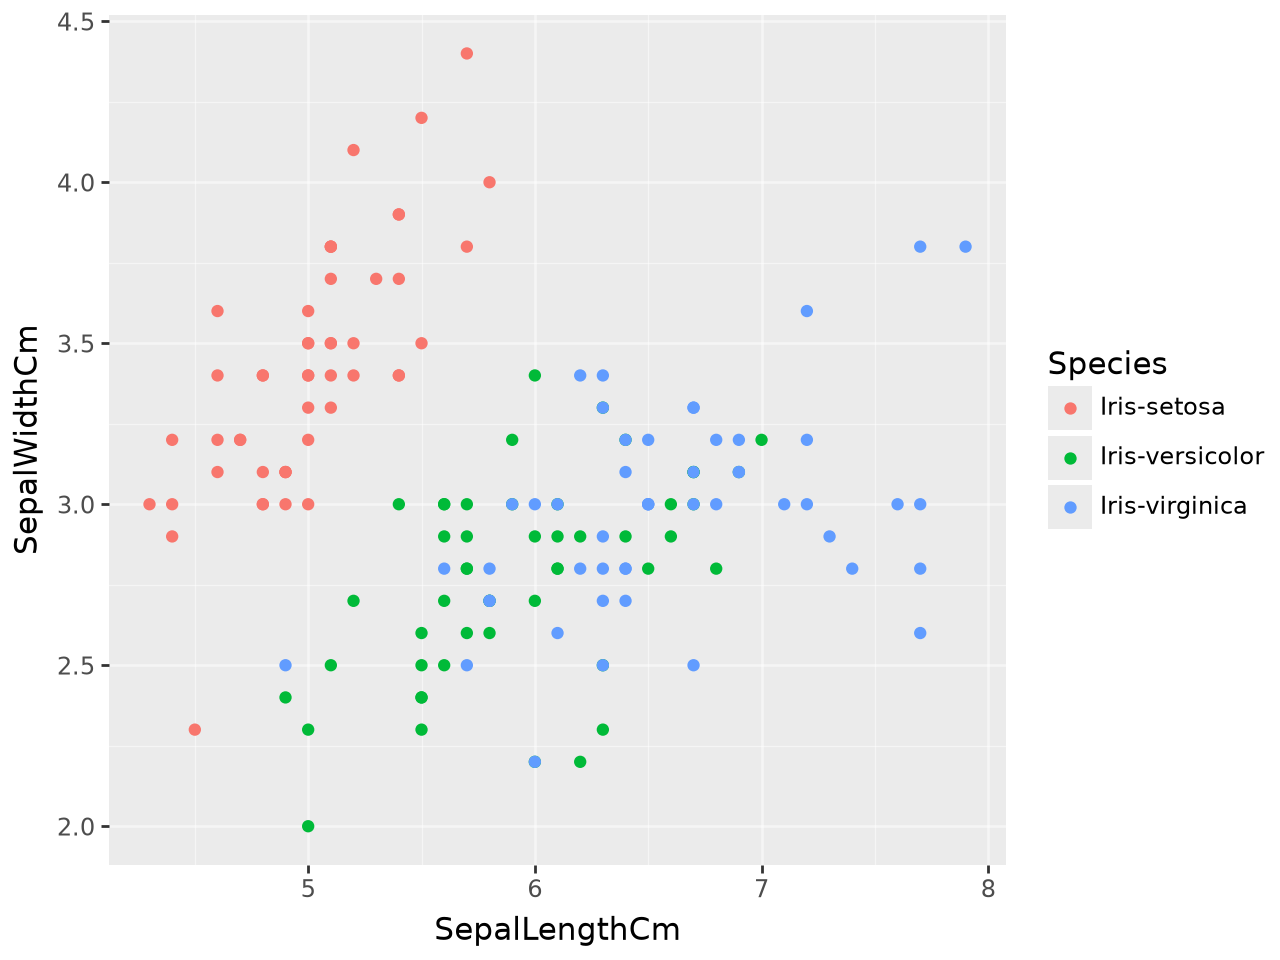

In [18]:
pln.ggplot(iris_df, pln.aes(x='SepalLengthCm', y='SepalWidthCm', color='Species')) + pln.geom_point()

Suppose we found an iris flower whose species is unknown, and we were able to measure only the length and width of its sepals. We obtained the following measurements:

In [19]:
data = {
    "SepalLengthCm": [5.3],
    "SepalWidthCm": [2.3],
}

new_data = pd.DataFrame(data)

new_data

,SepalLengthCm,SepalWidthCm
0,5.3,2.3


How can we determine the species of this specimen?

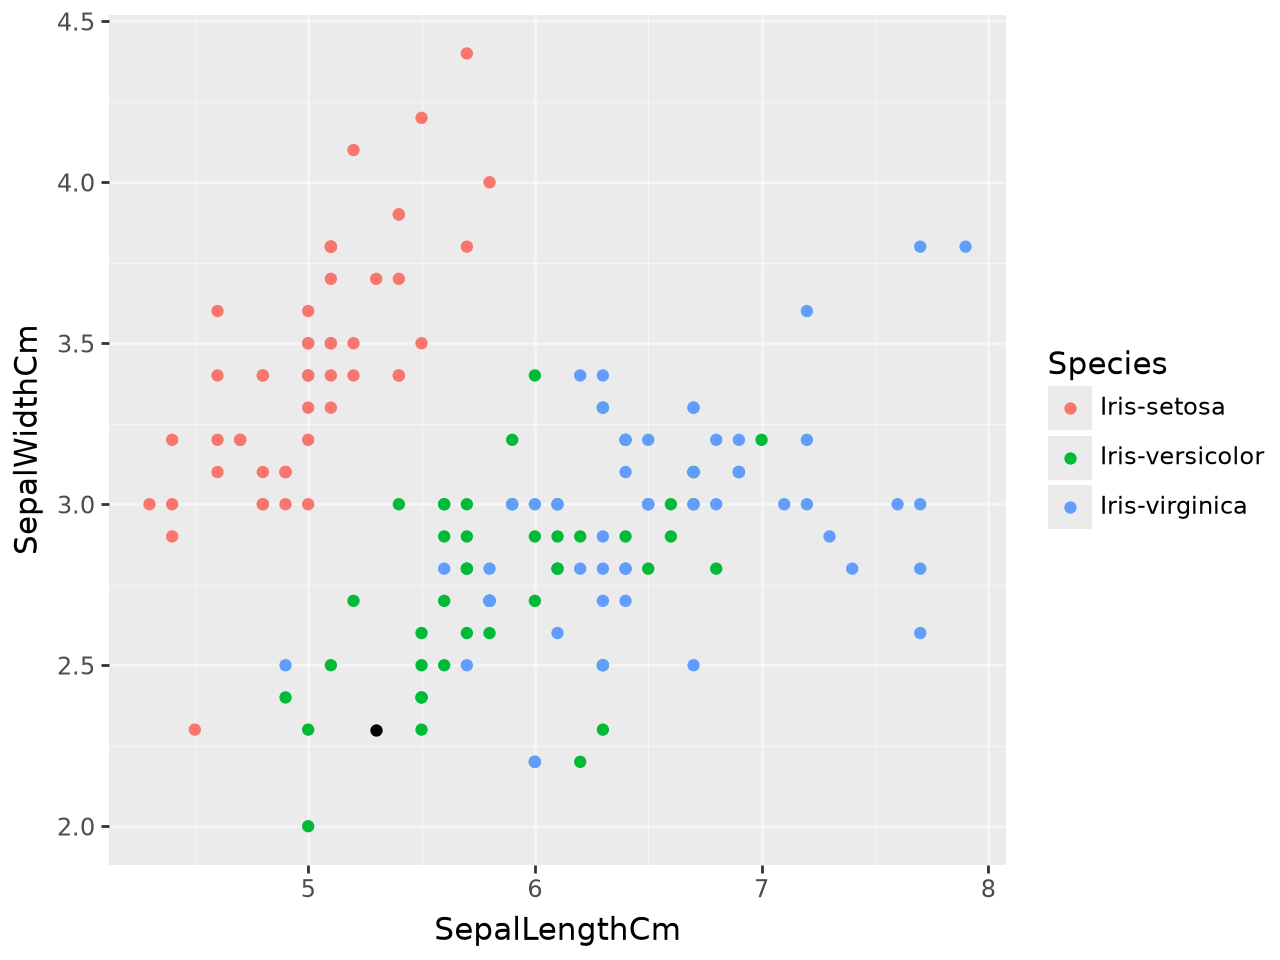

In [20]:
pln.ggplot() + \
    pln.geom_point(iris_df, pln.aes(x='SepalLengthCm', y='SepalWidthCm', color='Species')) + \
        pln.geom_point(new_data, pln.aes(x='SepalLengthCm', y='SepalWidthCm'), color='black')




KNN decides by (euclidean) distance, so a scatter plot shows us exactly what the model "sees".

Notice that *setosa* sits apart from the other two, while *versicolor* and *virginica* overlap heavily - using only the sepal measurements, these two species are hard to separate. That is why we should not expect a very high accuracy later on.

The following plot shows the eight nearest points—that is, the training samples with the smallest Euclidean distances from the new, unknown specimen.
Seven of these points are labeled Iris-versicolor, while only one is labeled Iris-virginica. Therefore, using the 8-nearest neighbors algorithm, the new specimen will be classified as Iris-versicolor.

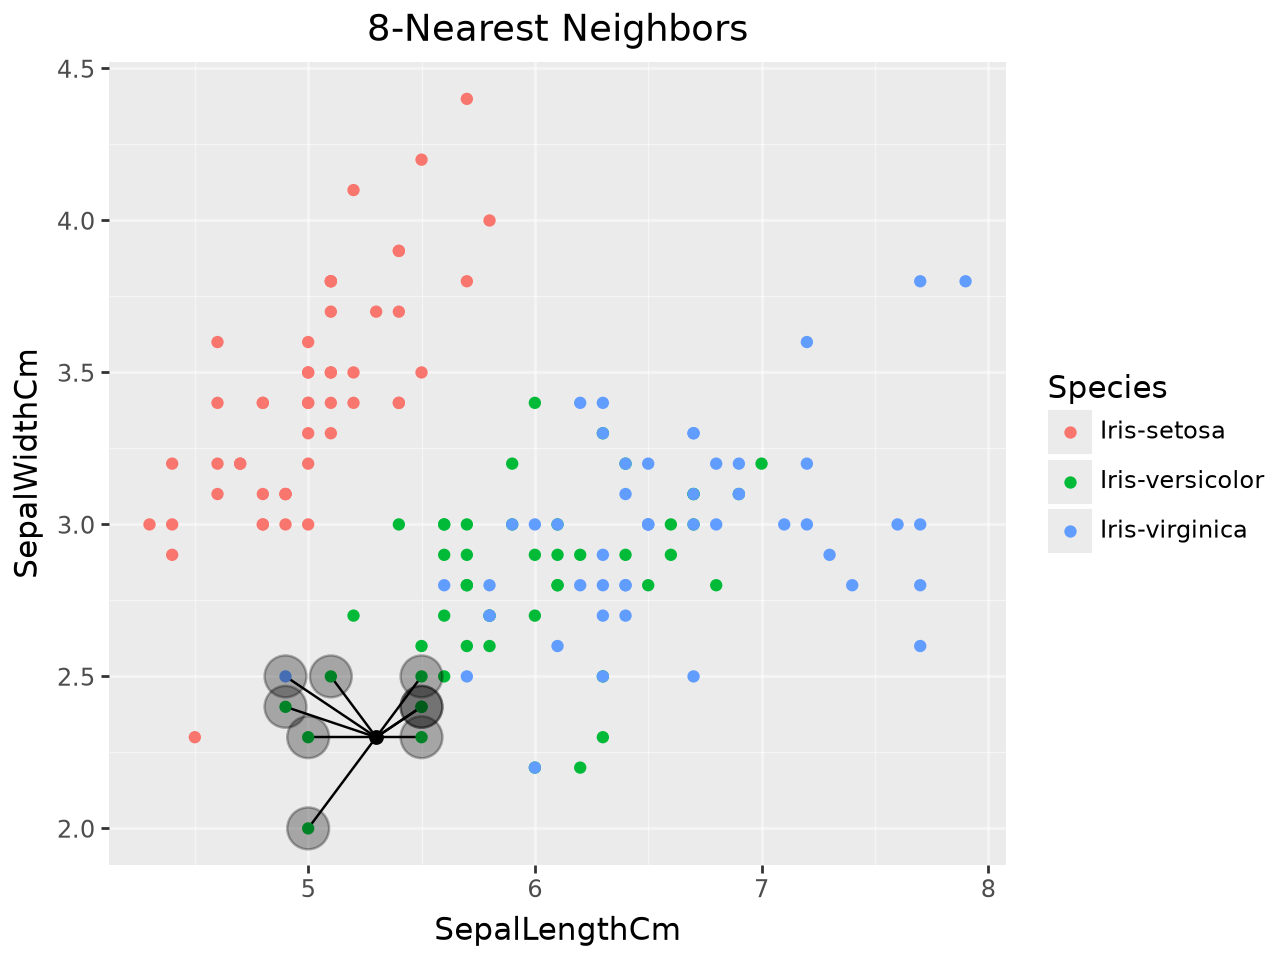

In [21]:
sample_df = iris_df.loc[(iris_df['SepalLengthCm'] < 5.6) & (iris_df['SepalLengthCm'] > 4.5) & (iris_df['SepalWidthCm'] < 2.6)]

lines_df = sample_df.assign(
      x=new_data['SepalLengthCm'].iloc[0],
      y=new_data['SepalWidthCm'].iloc[0],
  )

pln.ggplot() + \
    pln.geom_segment(lines_df, pln.aes(x='x', y='y', xend='SepalLengthCm', yend='SepalWidthCm')) + \
        pln.geom_point(iris_df, pln.aes(x='SepalLengthCm', y='SepalWidthCm', color='Species')) + \
            pln.geom_point(new_data, pln.aes(x='SepalLengthCm', y='SepalWidthCm'), color='black', size=2) + \
                pln.geom_point(sample_df, pln.aes(x='SepalLengthCm', y='SepalWidthCm'), color='black', size=8, alpha=0.3) + \
                    pln.xlab('SepalLengthCm') + pln.ylab('SepalWidthCm') + pln.ggtitle('8-Nearest Neighbors')

### Features (X) and labels (y)

* `X` holds the **features** - the measurements the model learns from.
* `y` holds the **label** - the answer we want to predict.

In [22]:
X = iris_df[["SepalLengthCm", "SepalWidthCm"]]
y = iris_df["Species"]

print(X.shape, y.shape)

(150, 2) (150,)


### Split into train and test sets

We must measure the model on data it has never seen, otherwise the score is meaningless (KNN would simply find each sample as its own nearest neighbor).

note:
* `test_size=0.3` keeps 30% of the rows for testing and 70% for training.
* `random_state=42` fixes the random shuffling, so you get the same split every run.
* `stratify=y` keeps the same proportion of each species in both sets.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("train:", X_train.shape, " test:", X_test.shape)

train: (105, 2)  test: (45, 2)


### Scale the features

KNN is based on distance, so a feature with a larger numeric range would dominate the distance calculation. `StandardScaler` rescales every column to mean 0 and standard deviation 1.

note:
* `fit_transform` on the **training** set: learns the mean/std *and* applies them.
* `transform` on the **test** set: applies the values learned from the training set.
* Never call `fit` on the test set - that would leak information from the test data into the model.

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.90045861, -1.21813584],
       [ 0.38036614, -1.8819988 ],
       [-0.90045861,  1.65860364],
       [ 1.07899781,  0.33087773],
       [-0.20182693, -0.55427288]])

### Train the KNN model

* `n_neighbors=5` - the k: how many neighbors vote.
* `fit(...)` - for KNN this only stores the training data.
* `predict(...)` - for each test sample, finds the 5 closest training samples and returns the majority species.

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred

array(['Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica'], dtype=object)

### Evaluate the model

* **accuracy** - the share of test samples that were classified correctly.
* **confusion matrix** - rows are the true species, columns are the predicted species. The diagonal holds the correct predictions; everything off the diagonal is a mistake.
* **classification report** - precision, recall and f1-score per species.

In [26]:
SPECIES = iris_df['Species'].unique()

In [27]:
print("accuracy:", round(accuracy_score(y_test, y_pred), 3))

cm = confusion_matrix(y_test, y_pred, labels=iris_df['Species'].unique())
print("\nconfusion matrix:")
print(pd.DataFrame(cm, index=["true " + s for s in iris_df['Species'].unique()],
                       columns=["pred " + s for s in iris_df['Species'].unique()]))

print("\nclassification report:")
print(classification_report(y_test, y_pred))

accuracy: 0.733

confusion matrix:
                      pred Iris-setosa  pred Iris-versicolor  \
true Iris-setosa                    15                     0   
true Iris-versicolor                 0                    10   
true Iris-virginica                  0                     7   

                      pred Iris-virginica  
true Iris-setosa                        0  
true Iris-versicolor                    5  
true Iris-virginica                     8  

classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.59      0.67      0.62        15
 Iris-virginica       0.62      0.53      0.57        15

       accuracy                           0.73        45
      macro avg       0.73      0.73      0.73        45
   weighted avg       0.73      0.73      0.73        45



### Choosing k

k is a **hyperparameter** - we choose it, the model does not learn it.
* A very small k (k=1) follows every single point, including noise - **overfitting**.
* A very large k averages over too many neighbors and blurs the classes - **underfitting**.

The loop below trains a model for every k from 1 to 25 and records the accuracy on both sets.

In [28]:
k_values = range(1, 26)
train_scores = []
test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

best_k = list(k_values)[int(np.argmax(test_scores))]
print("best k:", best_k, " test accuracy:", round(max(test_scores), 3))

best k: 4  test accuracy: 0.756


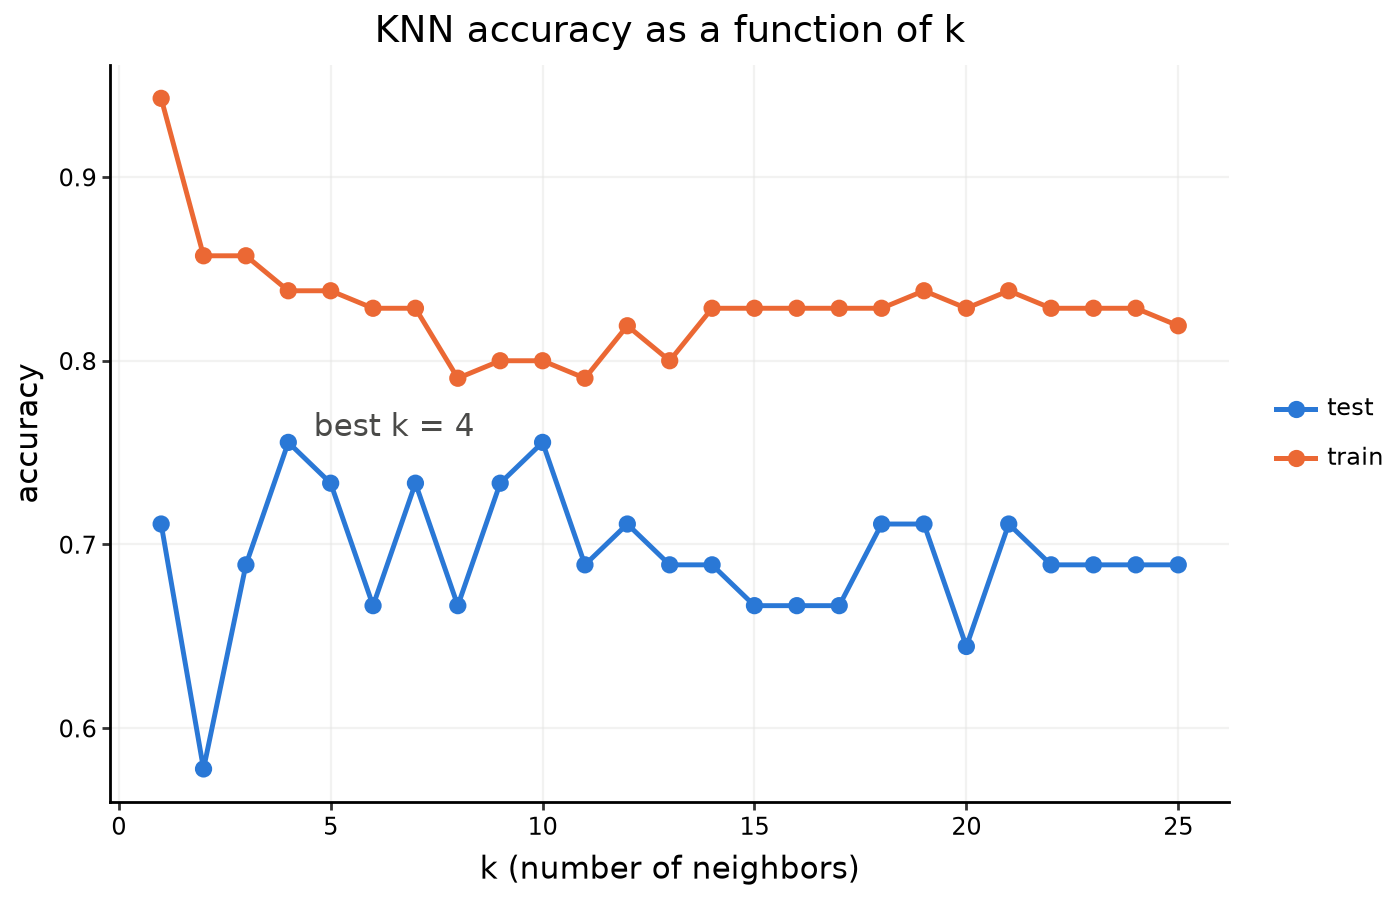

In [29]:
scores_df = pd.DataFrame({
    "k": list(k_values) * 2,
    "accuracy": list(test_scores) + list(train_scores),
    "dataset": ["test"] * len(k_values) + ["train"] * len(k_values),
})

(
    pln.ggplot(scores_df, pln.aes(x="k", y="accuracy", color="dataset"))
    + pln.geom_line(size=1)
    + pln.geom_point(size=2.5)
    + pln.scale_color_manual(values={"test": "#2a78d6", "train": "#eb6834"})
    + pln.annotate("text", x=best_k + 0.6, y=max(test_scores) + 0.01,
                   label=f"best k = {best_k}", color="#4a4a48", ha="left")
    + pln.labs(x="k (number of neighbors)", y="accuracy",
               title="KNN accuracy as a function of k", color="")
    + pln.theme_bw()
    + pln.theme(
        plot_background=pln.element_rect(fill="white", color="white"),
        panel_border=pln.element_blank(),
        axis_line=pln.element_line(color="black"),
        panel_grid_major=pln.element_line(color="#e6e6e4", size=0.8),
        panel_grid_minor=pln.element_blank(),
        axis_title=pln.element_text(color="black"),
        axis_text=pln.element_text(color="black"),
        legend_text=pln.element_text(color="black"),
        legend_title=pln.element_blank(),
        figure_size=(7, 4.5),
    )
)

### The decision boundary

Because we used only two features, we can draw the model itself: every point on the plane is classified, and the background color shows which species the model would predict there.

note:
* `np.meshgrid` builds a dense grid of points covering the plot area.
* `knn.predict` classifies all of them at once.
* `contourf` paints each region in the color of its predicted species.

Try re-running this cell with `k = 1` and with `k = 25` to see the boundary go from jagged (overfitting) to smooth.

In [30]:
SPECIES

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

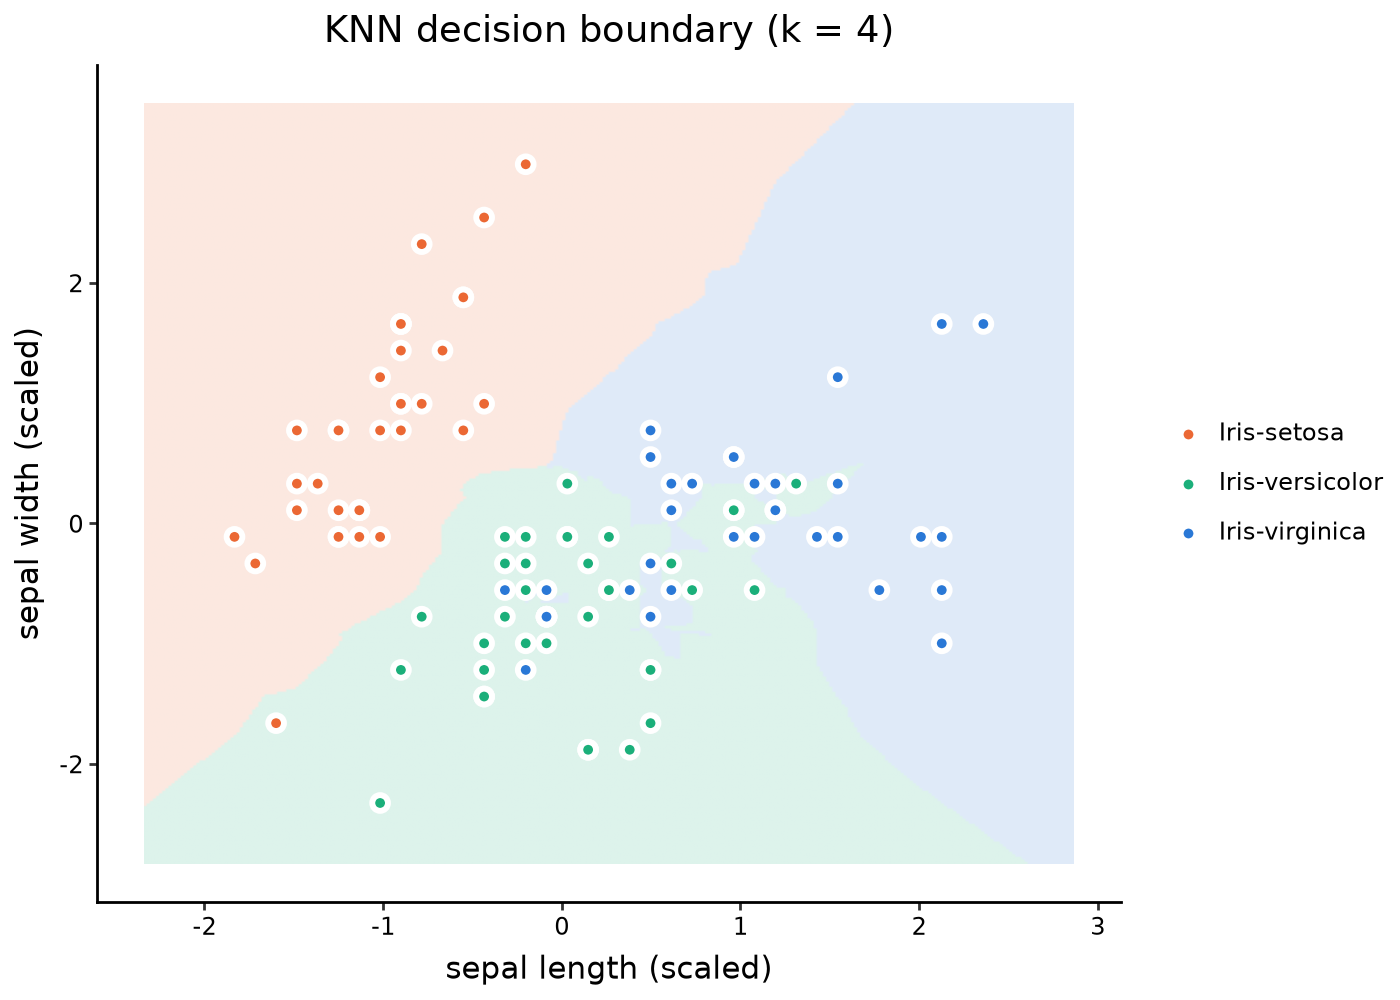

In [31]:
k = best_k
model = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)

# a grid over the scaled feature space
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid_pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
zz = np.searchsorted(SPECIES, grid_pred).reshape(xx.shape)

COLORS = {"Iris-setosa": "#eb6834", "Iris-versicolor": "#1baf7a", "Iris-virginica": "#2a78d6"}

species_arr = np.array(SPECIES)

grid_df = pd.DataFrame({
    "x": xx.ravel(),
    "y": yy.ravel(),
    "species": species_arr[zz.ravel()],
})

train_df = pd.DataFrame({
    "x": X_train_scaled[:, 0],
    "y": X_train_scaled[:, 1],
    "species": y_train.to_numpy(),
})

(
    pln.ggplot()
    + pln.geom_raster(grid_df, pln.aes(x="x", y="y", fill="species"),
                       alpha=0.15, show_legend=False, interpolate=False)
    + pln.geom_point(train_df, pln.aes(x="x", y="y", fill="species"),
                      color="white", stroke=1.2, size=2)
    + pln.scale_fill_manual(values=COLORS)
    + pln.labs(x="sepal length (scaled)", y="sepal width (scaled)",
               title=f"KNN decision boundary (k = {k})", fill="")
    + pln.theme_bw()
    + pln.theme(
        plot_background=pln.element_rect(fill="white", color="white"),
        panel_border=pln.element_blank(),
        axis_line=pln.element_line(color="black"),
        panel_grid_major=pln.element_blank(),
        panel_grid_minor=pln.element_blank(),
        axis_title=pln.element_text(color="black"),
        axis_text=pln.element_text(color="black"),
        legend_text=pln.element_text(color="black"),
        legend_title=pln.element_blank(),
        figure_size=(7, 5),
    )
)


### Predict a new flower

To classify a new measurement we must pass it through **the same scaler** that was fitted on the training data, and only then call `predict`.

`predict_proba` shows the vote: the share of the k neighbors that belonged to each species.

In [32]:
new_flowers = pd.DataFrame({
    "SepalLengthCm": [5.0, 6.2, 7.3],
    "SepalWidthCm":  [3.5, 2.8, 3.0],
})

new_scaled = scaler.transform(new_flowers)

new_flowers["predicted_species"] = knn.predict(new_scaled)

print(new_flowers)
print("\nvote share per species:")
print(pd.DataFrame(knn.predict_proba(new_scaled), columns=knn.classes_))

   SepalLengthCm  SepalWidthCm predicted_species
0            5.0           3.5       Iris-setosa
1            6.2           2.8    Iris-virginica
2            7.3           3.0    Iris-virginica

vote share per species:
   Iris-setosa  Iris-versicolor  Iris-virginica
0          1.0              0.0             0.0
1          0.0              0.4             0.6
2          0.0              0.0             1.0


---
# Part 2 - the same pipeline with all 4 features

With only the two sepal measurements we reached about 76% accuracy, and almost every mistake was *versicolor* confused with *virginica*.

The iris dataset has two more measurements - **petal length** and **petal width**. Let's run exactly the same steps on all four features and see how much they help.

### Build iris_df

Same source as before, but this time we keep all four measurement columns.

In [33]:
iris_df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

### Why the petals help

Plotting the two petal measurements the same way we plotted the sepals shows the difference immediately: the three species form three clean groups with almost no overlap. `groupby` confirms it - the average petal length grows sharply from species to species, while the average sepal width barely moves.

More informative features, not a cleverer algorithm, is what will improve the model here.

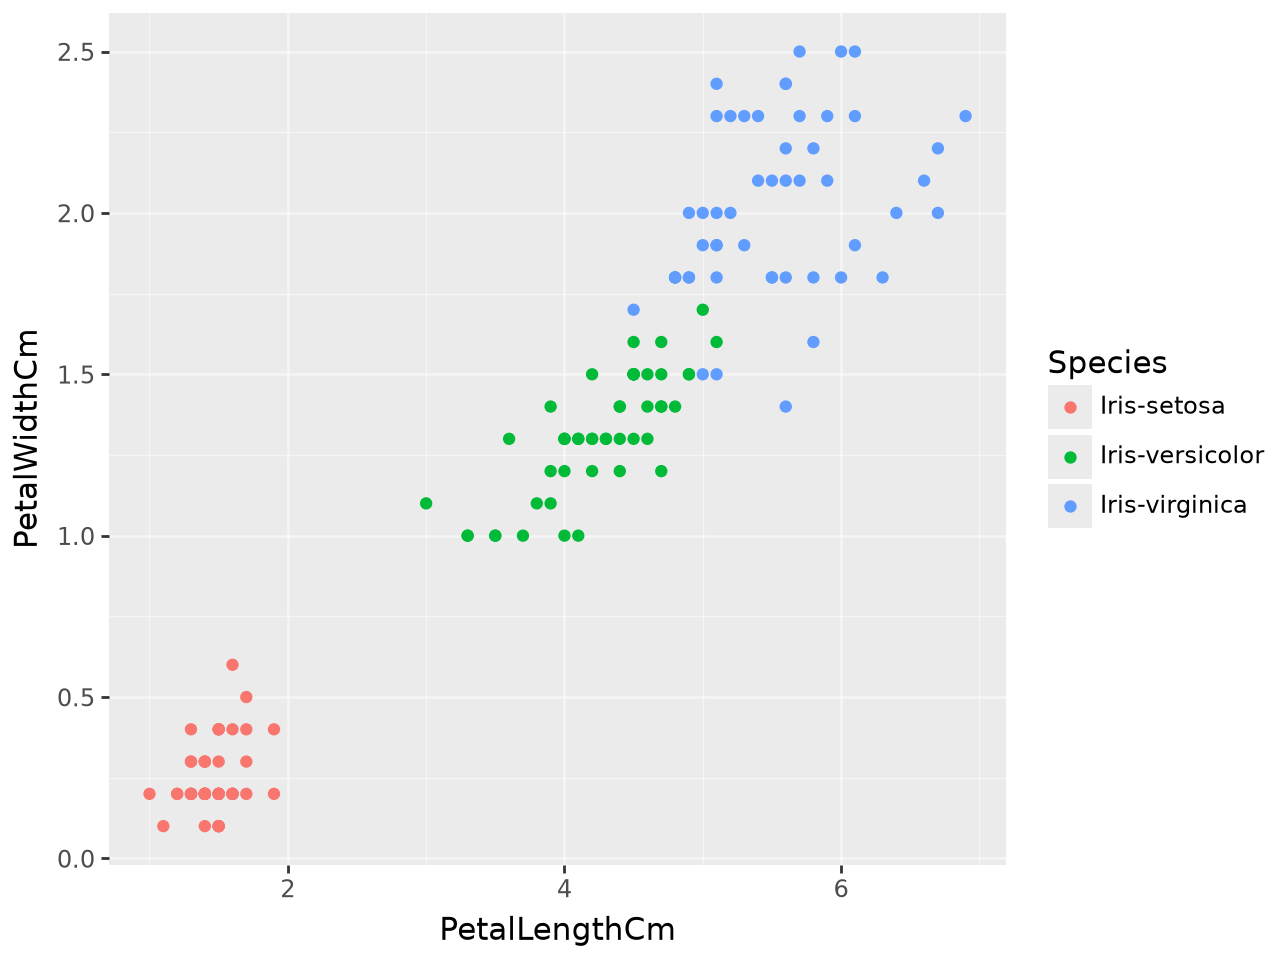

In [34]:
pln.ggplot(iris_df, pln.aes(x='PetalLengthCm', y='PetalWidthCm', color='Species')) + pln.geom_point()

### Split and scale

Exactly the same three steps as in part 1 - only `X` changed. We keep `random_state=42` and `stratify=y` so that the train/test split contains the very same rows as before; that way the comparison between the two models is fair.

Note that scaling matters more now: petal length ranges over about 6 cm while sepal width ranges over about 2.4 cm, so without scaling petal length would dominate the distance.

In [35]:
X_all = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y_all = iris_df["Species"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

print("train:", X_train_all.shape, " test:", X_test_all.shape)

train: (105, 4)  test: (45, 4)


### Train and evaluate

Same model, same k, same metrics - only the number of columns in `X` is different.

In [36]:
knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_train_all_scaled, y_train_all)

y_pred_all = knn_all.predict(X_test_all_scaled)

print("accuracy (2 sepal features):", round(accuracy_score(y_test, y_pred), 3))
print("accuracy (all 4 features)  :", round(accuracy_score(y_test_all, y_pred_all), 3))

cm_all = confusion_matrix(y_test_all, y_pred_all, labels=SPECIES)
print("\nconfusion matrix:")
print(pd.DataFrame(cm_all, index=["true " + s for s in SPECIES],
                           columns=["pred " + s for s in SPECIES]))

print("\nclassification report:")
print(classification_report(y_test_all, y_pred_all))

accuracy (2 sepal features): 0.733
accuracy (all 4 features)  : 0.911

confusion matrix:
                      pred Iris-setosa  pred Iris-versicolor  \
true Iris-setosa                    15                     0   
true Iris-versicolor                 0                    15   
true Iris-virginica                  0                     4   

                      pred Iris-virginica  
true Iris-setosa                        0  
true Iris-versicolor                    0  
true Iris-virginica                    11  

classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      1.00      0.88        15
 Iris-virginica       1.00      0.73      0.85        15

       accuracy                           0.91        45
      macro avg       0.93      0.91      0.91        45
   weighted avg       0.93      0.91      0.91        45



### Choosing k again

We repeat the k search on the four-feature data, and plot both test curves on the same axes so the gap between the two feature sets is visible at every k.

In [37]:
train_scores_all = []
test_scores_all = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_all_scaled, y_train_all)
    train_scores_all.append(m.score(X_train_all_scaled, y_train_all))
    test_scores_all.append(m.score(X_test_all_scaled, y_test_all))

best_k_all = list(k_values)[int(np.argmax(test_scores_all))]
print("best k:", best_k_all, " test accuracy:", round(max(test_scores_all), 3))

best k: 9  test accuracy: 0.956


In [38]:
SPECIES

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

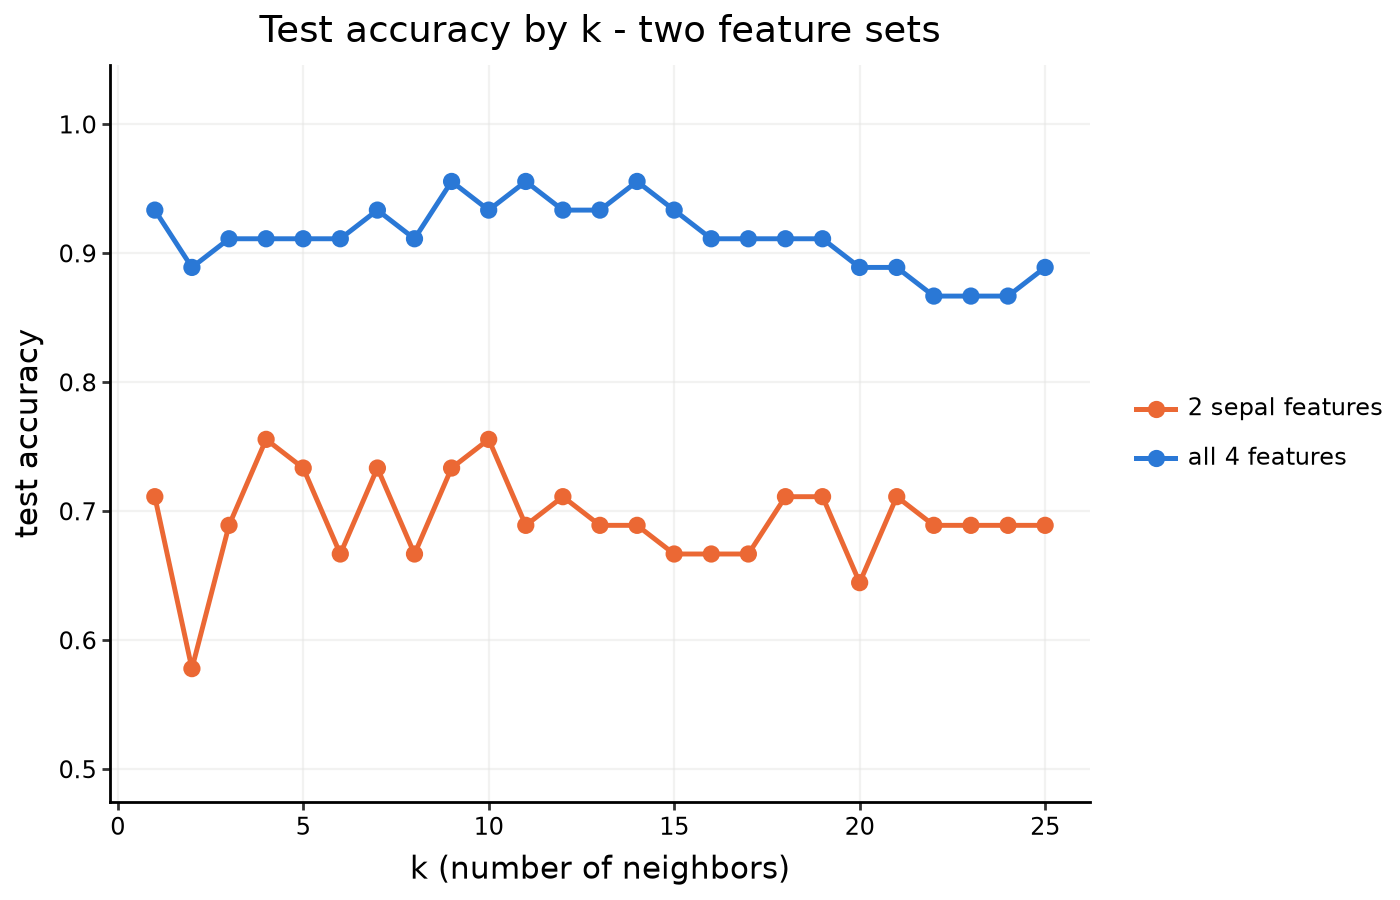

In [39]:
plt.show()
compare_df = pd.DataFrame({
    "k": list(k_values) * 2,
    "accuracy": list(test_scores_all) + list(test_scores),
    "feature_set": ["all 4 features"] * len(k_values) + ["2 sepal features"] * len(k_values),
})

(
        pln.ggplot(compare_df, pln.aes(x="k", y="accuracy", color="feature_set"))
        + pln.geom_line(size=1)
        + pln.geom_point(size=2.5)
        + pln.scale_color_manual(values={"all 4 features": "#2a78d6", "2 sepal features": "#eb6834"})
        + pln.scale_y_continuous(limits=(0.5, 1.02))
        + pln.labs(x="k (number of neighbors)", y="test accuracy",
                   title="Test accuracy by k - two feature sets", color="")
        + pln.theme_bw()
        + pln.theme(
    plot_background=pln.element_rect(fill="white", color="white"),
    panel_border=pln.element_blank(),
    axis_line=pln.element_line(color="black"),
    panel_grid_major=pln.element_line(color="#e6e6e4", size=0.8),
    panel_grid_minor=pln.element_blank(),
    axis_title=pln.element_text(color="black"),
    axis_text=pln.element_text(color="black"),
    legend_text=pln.element_text(color="black"),
    legend_title=pln.element_blank(),
    #legend_position=(0.9, 0.35),
    legend_background=pln.element_rect(fill="white", alpha=0),
    figure_size=(7, 4.5),
)
)

### Predict a new flower

The new measurements now need all four values, and they must go through `scaler_all` - the scaler that was fitted on the four-feature training set. Using the wrong scaler is a very common bug.

### Optional exercises

1. Re-run the model with `n_neighbors=1` and with `n_neighbors=25`. What happens to the train accuracy compared to the test accuracy?
2. Remove the scaling step (train on `X_train` instead of `X_train_scaled`). Does the accuracy change? Why is the effect small here, and when would it be large?
3. `KNeighborsClassifier` has a `weights` parameter. Compare `weights="uniform"` (the default) with `weights="distance"`.
4. Change `random_state` in the split to a few different values and see how much the test accuracy moves. What does that tell you about trusting a single split?
5. Build a `petal_df` from `iris.frame` using the two **petal** columns instead, and run the same pipeline. Which pair of measurements separates the species better?
6. Use all four measurements at once. How high can the accuracy get?